# Анализ медицинских данных

## Набор 1: клиническое исследование

В этой тетрадке:
- загрузка данных и проверка корректности
- визуальный анализ (гистограммы, бокс‑плоты)
- проверка предпосылок (Шапиро–Уилка, Левен)
- выбор теста и проверка гипотезы
- размер эффекта (коэн d)


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_theme()


## Задание 1. Подготовка окружения и знакомство с данными

По заданию файл: `src/clinical_trial_data.csv`.
Код ниже ищет файл по нескольким вариантам имён.


In [2]:
from pathlib import Path

candidates = [
    Path("clinical_trial_data.csv"),
    Path("src/clinical_trial_data.csv"),
    Path("clinical_trial_data222.csv"),
    Path("src/clinical_trial_data222.csv"),
]

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Не найден clinical_trial_data.csv (или clinical_trial_data222.csv).")

print("Использую файл:", data_path)

df = pd.read_csv(data_path)
df.head()


Использую файл: clinical_trial_data.csv


,PatientID,Group,Score
0,1,Placebo,60.870471
1,2,Drug,63.997831
2,3,Placebo,60.917608
3,4,Placebo,40.124311
4,5,Placebo,57.803281


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PatientID  200 non-null    int64  
 1   Group      200 non-null    object 
 2   Score      200 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.8+ KB


In [4]:
df.isna().sum()


PatientID    0
Group        0
Score        0
dtype: int64

In [5]:
df.describe(include="all")


,PatientID,Group,Score
count,200.000000,200,200.000000
unique,NaN,2,NaN
top,NaN,Placebo,NaN
freq,NaN,100,NaN
mean,100.500000,NaN,65.267600
std,57.879185,NaN,11.088616
min,1.000000,NaN,39.748574
25%,50.750000,NaN,58.021821
50%,100.500000,NaN,65.135267
75%,150.250000,NaN,72.504527


Если названия столбцов отличаются — поменяй `group_col` и `score_col`.

In [6]:
group_col = "Group"
score_col = "Score"

if group_col not in df.columns or score_col not in df.columns:
    raise KeyError(f"Ожидаю столбцы {group_col!r} и {score_col!r}. В датасете есть: {list(df.columns)}")

df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

df[[group_col, score_col]].head()


,Group,Score
0,Placebo,60.870471
1,Drug,63.997831
2,Placebo,60.917608
3,Placebo,40.124311
4,Placebo,57.803281


## Задание 2. Визуальный анализ

Гистограммы и бокс‑плот по двум группам.

In [7]:
groups = df[group_col].dropna().unique().tolist()
print("Найденные группы:", groups)

if len(groups) != 2:
    raise ValueError("Ожидаю ровно 2 группы.")

g0, g1 = groups[0], groups[1]
x0 = df.loc[df[group_col] == g0, score_col].dropna()
x1 = df.loc[df[group_col] == g1, score_col].dropna()

print(f"{g0}: n={len(x0)}, среднее={x0.mean():.3f}, ско={x0.std(ddof=1):.3f}")
print(f"{g1}: n={len(x1)}, среднее={x1.mean():.3f}, ско={x1.std(ddof=1):.3f}")


Найденные группы: ['Placebo', 'Drug']
Placebo: n=100, среднее=60.686, ско=10.538
Drug: n=100, среднее=69.849, ско=9.680


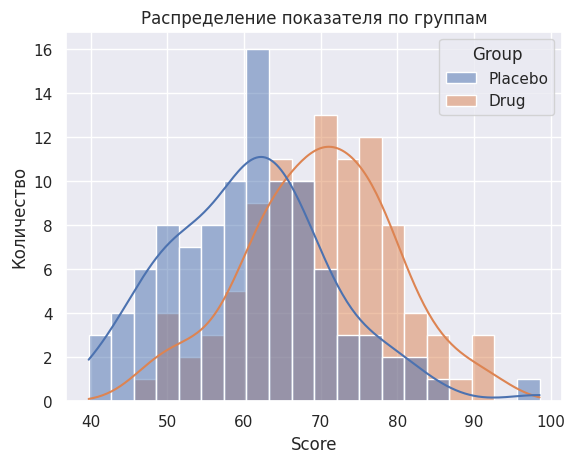

In [8]:
plt.figure()
sns.histplot(data=df, x=score_col, hue=group_col, kde=True, bins=20)
plt.title("Распределение показателя по группам")
plt.xlabel(score_col)
plt.ylabel("Количество")
plt.show()


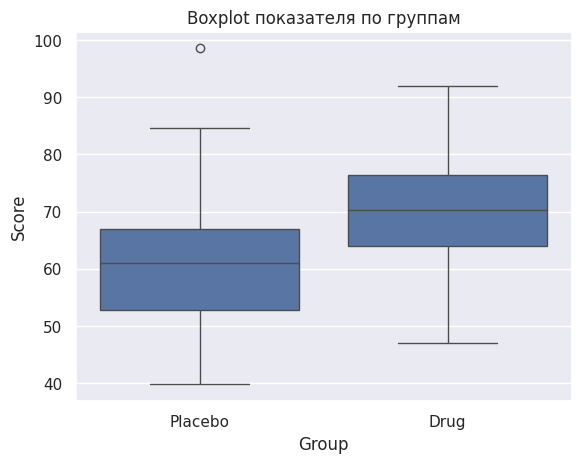

In [9]:
plt.figure()
sns.boxplot(data=df, x=group_col, y=score_col)
plt.title("Boxplot показателя по группам")
plt.xlabel(group_col)
plt.ylabel(score_col)
plt.show()


### Выводы
По гистограммам видно, что распределение показателей самочувствия в группе препарата смещено вправо относительно группы плацебо: у пациентов, принимающих препарат, чаще встречаются более высокие значения, а низкие значения встречаются реже.

Boxplot подтверждает это наблюдение: медиана в группе препарата заметно выше, чем в группе плацебо, и весь «ящик» (межквартильный размах) у препарата расположен выше, то есть типичные значения самочувствия в группе препарата в целом лучше. Перекрытие между группами есть, но общая картина устойчиво указывает на преимущество препарата по уровню самочувствия по сравнению с плацебо.

## Задание 3. Проверка предпосылок и проверка гипотезы

- Шапиро–Уилка (нормальность)
- Левен (равенство дисперсий)
- выбор т‑теста или Манна–Уитни
- коэн d


In [10]:
alpha = 0.05

sh0 = stats.shapiro(x0)
sh1 = stats.shapiro(x1)

print("Шапиро–Уилка")
print(f"  {g0}: статистика={sh0.statistic:.6f}, p={sh0.pvalue:.6f}")
print(f"  {g1}: статистика={sh1.statistic:.6f}, p={sh1.pvalue:.6f}")

lev = stats.levene(x0, x1, center="median")
print("\nЛевен")
print(f"  статистика={lev.statistic:.6f}, p={lev.pvalue:.6f}")

normal_ok = (sh0.pvalue >= alpha) and (sh1.pvalue >= alpha)
var_ok = (lev.pvalue >= alpha)

print("\nУсловия:")
print("  нормальность:", "да" if normal_ok else "нет")
print("  равенство дисперсий:", "да" if var_ok else "нет")

if normal_ok and var_ok:
    res = stats.ttest_ind(x0, x1, equal_var=True)
    test_name = "т‑тест (независимые выборки, равные дисперсии)"
    stat, pval = res.statistic, res.pvalue
else:
    res = stats.mannwhitneyu(x0, x1, alternative="two-sided")
    test_name = "Манна–Уитни"
    stat, pval = res.statistic, res.pvalue

print("\nВыбранный тест:", test_name)
print(f"Статистика={stat:.6f}, p={pval:.10f}")
print("Решение при α=0.05:", "есть статистически значимая разница" if pval < alpha else "статистически значимой разницы нет")

def cohens_d(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    na, nb = len(a), len(b)
    sa2 = a.var(ddof=1)
    sb2 = b.var(ddof=1)
    sp = np.sqrt(((na - 1) * sa2 + (nb - 1) * sb2) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp

d = cohens_d(x0, x1)
print("\nКоэн d (", g0, "-", g1, "):", d)


Шапиро–Уилка
  Placebo: статистика=0.980756, p=0.152162
  Drug: статистика=0.989422, p=0.618060

Левен
  статистика=0.379709, p=0.538467

Условия:
  нормальность: да
  равенство дисперсий: да

Выбранный тест: т‑тест (независимые выборки, равные дисперсии)
Статистика=-6.403186, p=0.0000000011
Решение при α=0.05: есть статистически значимая разница

Коэн d ( Placebo - Drug ): -0.9055472649662838
